In [119]:
import os
os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ.get("PATH", "")

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
import pickle
import h5py
import scienceplots


plt.style.use(["science", "vibrant"])
plt.rcParams["font.family"] = "sans-serif"


plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'figure.titlesize': 20
})

In [120]:
data_dir = Path("data")
file_path_100ps = data_dir / "strain_wave_phi_scan_dict_0.h5"
file_path_1ns = data_dir / "strain_wave_phi_scan_dict_1.h5"
file_path_2ns = data_dir / "strain_wave_phi_scan_dict_2.h5"
file_path_3ns = data_dir / "strain_wave_phi_scan_dict_3.h5"
file_path_3_small_beam = data_dir / "strain_wave_phi_scan_dict_3_small_beam.h5"
file_path_0_small_beam = data_dir / "strain_wave_phi_scan_dict_0_small_beam.h5"
# file_path_4ns = data_dir / "strain_wave_phi_scan_dict_4.h5"
file_path_5ns = data_dir / "strain_wave_phi_scan_dict.h5"
# file_path_6ns = data_dir / "strain_wave_phi_scan_dict_6.h5"

psize = 40e-9
two_theta = 35.04
Nx, Ny, Nz = 600, 10, 200


def read_geometry_from_h5(path):
    psize_out = psize
    two_theta_out = two_theta
    nx_out, ny_out, nz_out = Nx, Ny, Nz
    with h5py.File(path, "r") as hf:
        if "psize" in hf.attrs:
            psize_out = float(hf.attrs["psize"])
        if "two_theta" in hf.attrs:
            two_theta_out = float(hf.attrs["two_theta"])
        if "forward_model" in hf and "Npixels" in hf["forward_model"]:
            npix = np.asarray(hf["forward_model"]["Npixels"][:], dtype=int).ravel()
            if npix.size >= 3:
                nx_out = int(npix[0])
                ny_out = int(npix[1])
                nz_out = int(npix[2])
    return psize_out, two_theta_out, nx_out, ny_out, nz_out


if file_path_100ps.is_file():
    psize, two_theta, Nx, Ny, Nz = read_geometry_from_h5(file_path_100ps)

theta = np.deg2rad(two_theta / 2)
det_x = ((-psize * Nx / 2) + psize / 2 + np.arange(Nx) * psize) / np.tan(2 * theta)
det_y = (-psize * Ny / 2) + psize / 2 + np.arange(Ny) * psize
det_x_um = det_x * 1e6
det_y_um = det_y * 1e6


In [121]:
def load_phi_scan(path_h5):
    path_h5 = Path(path_h5)
    if path_h5.is_file():
        with h5py.File(path_h5, "r") as hf:
            grp = hf["phi_scan"] if "phi_scan" in hf else hf
            phi_values = np.asarray(grp["phi_values"][:], dtype=float)
            images = np.asarray(grp["images"][:])
        out = {}
        for idx, phi in enumerate(phi_values):
            out[float(phi)] = images[idx]
        return out


imstack_100ps = load_phi_scan(file_path_100ps)
imstack_1ns = load_phi_scan(file_path_1ns)
imstack_2ns = load_phi_scan(file_path_2ns)
imstack_3ns = load_phi_scan(file_path_3ns)
imstack_5ns = load_phi_scan(file_path_5ns)
imstack_3_small_beam = load_phi_scan(file_path_3_small_beam)
imstack_0_small_beam = load_phi_scan(file_path_0_small_beam)


In [122]:
imstack_100ps.keys()

dict_keys([-0.0005235987755982988, -0.0004712388980384689, -0.00041887902047863906, -0.00036651914291880916, -0.0003141592653589793, -0.0002617993877991494, -0.0002094395102393195, -0.00015707963267948965, -0.00010471975511965975, -5.235987755982985e-05, 0.0, 5.23598775598299e-05, 0.0001047197551196598, 0.0001570796326794897, 0.0002094395102393195, 0.0002617993877991494, 0.0003141592653589793, 0.0003665191429188092, 0.0004188790204786391, 0.000471238898038469, 0.0005235987755982988])

In [123]:
def compute_COM(frames, varying_arr, sigma=0, min_total_intensity=1e-12):
    frames_filt = np.stack([ndi.gaussian_filter(frame, sigma) for frame in frames])
    frames_filt = np.clip(frames_filt, 0.0, None)
    varying = np.asarray(varying_arr, dtype=float)[:, None, None]
    weighted_sum = np.sum(varying * frames_filt, axis=0)
    total = np.sum(frames_filt, axis=0)
    com = np.full(total.shape, np.nan, dtype=float)
    valid = total > min_total_intensity
    com[valid] = weighted_sum[valid] / total[valid]
    return com

# def compute_COM(frames, varying_arr, sigma=2):
#     frames = np.stack([ndi.gaussian_filter(frame, sigma) for frame in frames])
#     phi_max= np.argmax(frames, axis=0)
#     phi_values_rad = np.array(sorted(imstack_100ps.keys()), dtype=float)
#     phi_values = np.rad2deg(phi_values_rad)
#     phi_max = phi_values[phi_max]
#     return phi_max

# from scipy.optimize import curve_fit

# def gaussian(x, a, x0, sigma, offset):
#     return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + offset

# def compute_COM(frames, varying_arr, sigma=0):
#     frames = np.stack([ndi.gaussian_filter(frame, sigma) for frame in frames])
#     varying_arr = np.asarray(varying_arr, dtype=float)
#     shape = frames.shape[1:]
#     phi_peak = np.full(shape, np.nan)
#     for idx in np.ndindex(shape):
#         curve = frames[:, idx[0], idx[1]]
#         if np.all(curve <= 0):
#             continue
#         try:
#             amp = curve.max() - curve.min()
#             mu = varying_arr[np.argmax(curve)]
#             sig = (varying_arr.max() - varying_arr.min()) / 4
#             offset = curve.min()
#             p0 = [amp, mu, sig, offset]
#             popt, _ = curve_fit(gaussian, varying_arr, curve, p0=p0)
#             phi_peak[idx] = popt[1]
#         except Exception:
#             phi_peak[idx] = np.nan
#     return phi_peak


In [124]:
phi_values_rad_100ps = np.array(sorted(imstack_100ps.keys()), dtype=float)
phi_values_100ps = np.rad2deg(phi_values_rad_100ps)
varying_arr_100ps = np.array(phi_values_100ps)


frames_100ps = np.stack([imstack_100ps[phi] for phi in phi_values_rad_100ps])

com_100ps = compute_COM(frames_100ps, varying_arr_100ps)


In [125]:
phi_values_rad_1ns = np.array(sorted(imstack_1ns.keys()), dtype=float)
phi_values_1ns = np.rad2deg(phi_values_rad_1ns)
varying_arr_1ns = np.array(phi_values_1ns)

frames_1ns = np.stack([imstack_1ns[phi] for phi in phi_values_rad_1ns])

com_1ns = compute_COM(frames_1ns, varying_arr_1ns)

In [126]:
phi_values_rad_2ns = np.array(sorted(imstack_2ns.keys()), dtype=float)
phi_values_2ns = np.rad2deg(phi_values_rad_2ns)
varying_arr_2ns = np.array(phi_values_2ns)

frames_2ns = np.stack([imstack_2ns[phi] for phi in phi_values_rad_2ns])

com_2ns = compute_COM(frames_2ns, varying_arr_2ns)


In [127]:
phi_values_rad_3ns = np.array(sorted(imstack_3ns.keys()), dtype=float)
phi_values_3ns = np.rad2deg(phi_values_rad_3ns)
varying_arr_3ns = np.array(phi_values_3ns)

frames_3ns = np.stack([imstack_3ns[phi] for phi in phi_values_rad_3ns])

com_3ns = compute_COM(frames_3ns, varying_arr_3ns)

In [128]:
phi_values_rad_5ns = np.array(sorted(imstack_5ns.keys()), dtype=float)
phi_values_5ns = np.rad2deg(phi_values_rad_5ns)
varying_arr_5ns = np.array(phi_values_5ns)

frames_5ns = np.stack([imstack_5ns[phi] for phi in phi_values_rad_5ns])

com_5ns = compute_COM(frames_5ns, varying_arr_5ns)

In [129]:
phi_values_rad_3_small_beam = np.array(sorted(imstack_3_small_beam.keys()), dtype=float)
phi_values_3_small_beam = np.rad2deg(phi_values_rad_3_small_beam)
varying_arr_3_small_beam = np.array(phi_values_3_small_beam)

frames_3_small_beam = np.stack([imstack_3_small_beam[phi] for phi in phi_values_rad_3_small_beam])

com_3_small_beam = compute_COM(frames_3_small_beam, varying_arr_3_small_beam)

In [130]:
phi_values_rad_0_small_beam = np.array(sorted(imstack_0_small_beam.keys()), dtype=float)
phi_values_0_small_beam = np.rad2deg(phi_values_rad_0_small_beam)
varying_arr_0_small_beam = np.array(phi_values_0_small_beam)

frames_0_small_beam = np.stack([imstack_0_small_beam[phi] for phi in phi_values_rad_0_small_beam])

com_0_small_beam = compute_COM(frames_0_small_beam, varying_arr_0_small_beam)

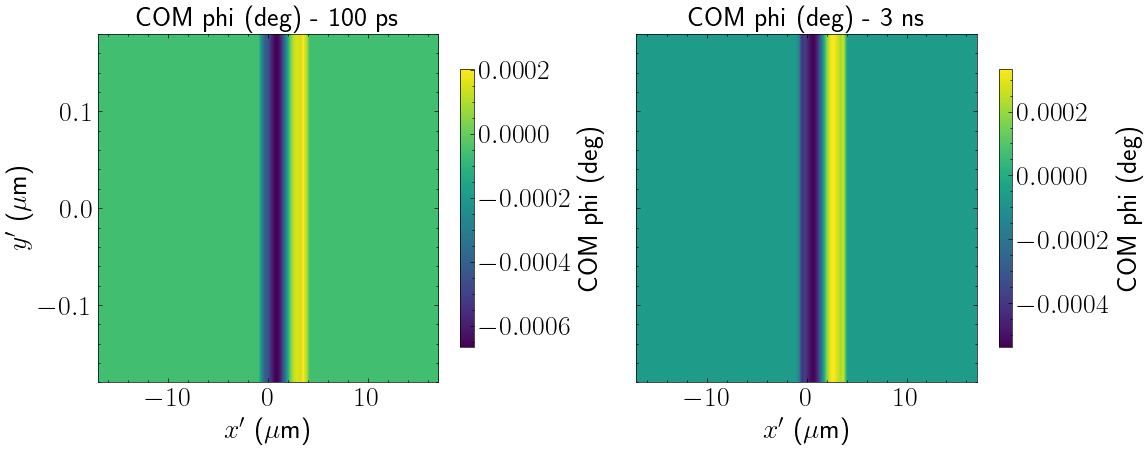

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# 100ps
im0 = axes[0].imshow(
    com_100ps.T,
    origin='lower',
    extent=[det_x_um.min(), det_x_um.max(), det_y_um.min(), det_y_um.max()],
    aspect='auto',
)
axes[0].set_title("COM phi (deg) - 100 ps")
axes[0].set_xlabel(r"$x'$ ($\mu$m)")
axes[0].set_ylabel(r"$y'$ ($\mu$m)")
cbar0 = plt.colorbar(im0, ax=axes[0], shrink=0.8)
cbar0.set_label('COM phi (deg)')

# 3ns
im1 = axes[1].imshow(
    com_1ns.T,
    origin='lower',
    extent=[det_x_um.min(), det_x_um.max(), det_y_um.min(), det_y_um.max()],
    aspect='auto',
)
axes[1].set_title("COM phi (deg) - 3 ns")
axes[1].set_xlabel(r"$x'$ ($\mu$m)")
cbar1 = plt.colorbar(im1, ax=axes[1], shrink=0.8)
cbar1.set_label('COM phi (deg)')

plt.tight_layout()
plt.show()


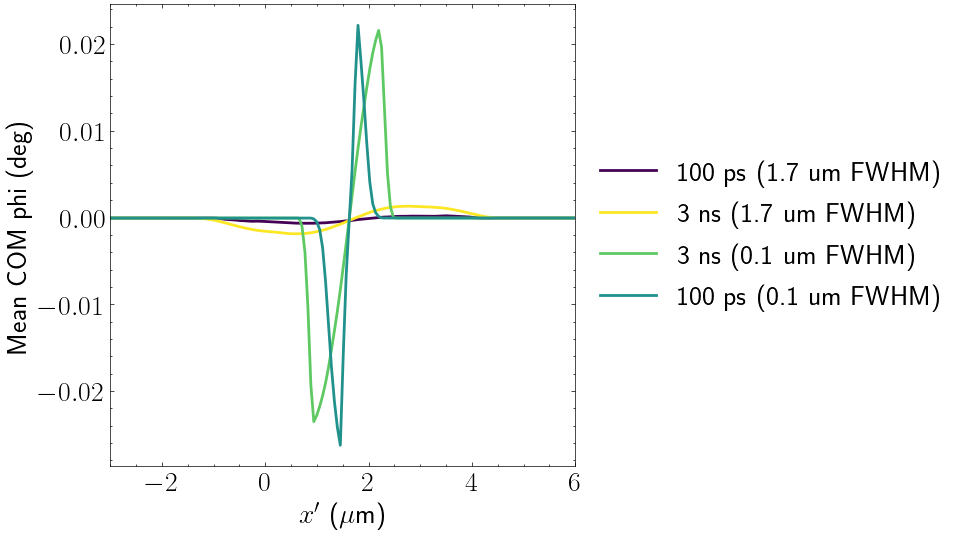

In [143]:
# get colormap
cm = plt.get_cmap('viridis')

fig, ax = plt.subplots(figsize=(6, 6))

valid_rows_100ps = np.any(np.isfinite(com_100ps), axis=1)
one_d_com_100ps = np.full(com_100ps.shape[0], np.nan, dtype=float)
one_d_com_100ps[valid_rows_100ps] = np.mean(com_100ps[valid_rows_100ps], axis=1)

valid_rows_1ns = np.any(np.isfinite(com_1ns), axis=1)
one_d_com_1ns = np.full(com_1ns.shape[0], np.nan, dtype=float)
one_d_com_1ns[valid_rows_1ns] = np.mean(com_1ns[valid_rows_1ns], axis=1)

valid_rows_2ns = np.any(np.isfinite(com_2ns), axis=1)   
one_d_com_2ns = np.full(com_2ns.shape[0], np.nan, dtype=float)
one_d_com_2ns[valid_rows_2ns] = np.mean(com_2ns[valid_rows_2ns], axis=1)

valid_rows_3ns = np.any(np.isfinite(com_3ns), axis=1)
one_d_com_3ns = np.full(com_3ns.shape[0], np.nan, dtype=float)
one_d_com_3ns[valid_rows_3ns] = np.mean(com_3ns[valid_rows_3ns], axis=1)

valid_rows_5ns = np.any(np.isfinite(com_5ns), axis=1)
one_d_com_5ns = np.full(com_5ns.shape[0], np.nan, dtype=float)
one_d_com_5ns[valid_rows_5ns] = np.mean(com_5ns[valid_rows_5ns], axis=1)

valid_rows_3_small_beam = np.any(np.isfinite(com_3_small_beam), axis=1)
one_d_com_3_small_beam = np.full(com_3_small_beam.shape[0], np.nan, dtype=float)
one_d_com_3_small_beam[valid_rows_3_small_beam] = np.mean(com_3_small_beam[valid_rows_3_small_beam], axis=1)

valid_rows_0_small_beam = np.any(np.isfinite(com_0_small_beam), axis=1)
one_d_com_0_small_beam = np.full(com_0_small_beam.shape[0], np.nan, dtype=float)
one_d_com_0_small_beam[valid_rows_0_small_beam] = np.mean(com_0_small_beam[valid_rows_0_small_beam], axis=1)

# Select 5 distinct colors from the 'viridis' colormap
colors = cm(np.linspace(0, 1, 5))

plt.plot(det_x_um, one_d_com_100ps, label='100 ps (1.7 um FWHM)', linewidth=2, color=colors[0])
# plt.plot(det_x_um, one_d_com_1ns, label='1 ns', linewidth=2, color=colors[1])
# plt.plot(det_x_um, one_d_com_2ns, label='2 ns', linewidth=2, color=colors[3])
plt.plot(det_x_um, one_d_com_3ns, label='3 ns (1.7 um FWHM)', linewidth=2, color=colors[4])
plt.plot(det_x_um, one_d_com_3_small_beam, label='3 ns (0.1 um FWHM)', linewidth=2, color=colors[3])
plt.plot(det_x_um, one_d_com_0_small_beam, label='100 ps (0.1 um FWHM)', linewidth=2, color=colors[2])
# plt.plot(det_x_um, one_d_com_5ns, label='5 ns', linewidth=2, color=colors[2])
plt.xlim(-3, 6)
plt.xlabel(r"$x'$ ($\mu$m)")
plt.ylabel('Mean COM phi (deg)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()


In [133]:
strain_profile_file_3ns = 'strain_profile_3ns.csv'
strain_profile_file_100ps = 'strain_profile_100ps.csv'
strain_profile_3ns = np.genfromtxt(strain_profile_file_3ns, delimiter=',', names=True)
strain_profile_100ps = np.genfromtxt(strain_profile_file_100ps, delimiter=',', names=True)
profile_xs_m_3ns = strain_profile_3ns['distance_nm'] * 1e-9
profile_exx_3ns = strain_profile_3ns['strain']
profile_xs_m_100ps = strain_profile_100ps['distance_nm'] * 1e-9
profile_exx_100ps = strain_profile_100ps['strain']


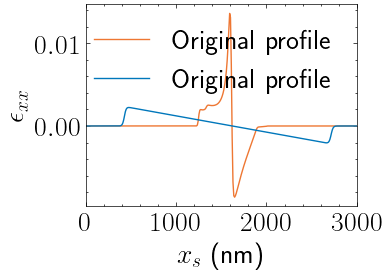

In [134]:
plt.plot(profile_xs_m_100ps * 1e9, profile_exx_100ps, label='Original profile')
plt.plot(profile_xs_m_3ns * 1e9, profile_exx_3ns, label='Original profile')
plt.xlabel(r'$x_s$ (nm)')
plt.ylabel(r'$\epsilon_{xx}$')
plt.xlim(0, 3000)
plt.legend()
plt.show()

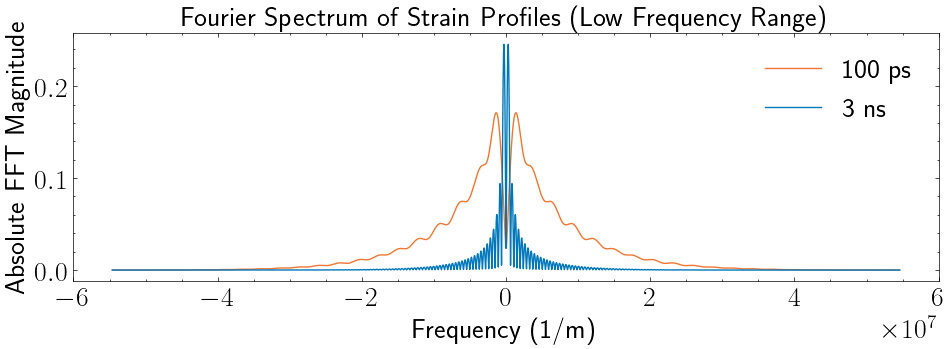

In [135]:
from scipy.fft import fft, fftfreq, fftshift

# FFT for 100 ps
N_100ps = len(profile_exx_100ps)
dx_100ps = np.mean(np.diff(profile_xs_m_100ps))
fft_100ps = fft(profile_exx_100ps)
freq_100ps = fftfreq(N_100ps, d=dx_100ps)
fft_100ps_abs = np.abs(fft_100ps)

# FFT for 3 ns
N_3ns = len(profile_exx_3ns)
dx_3ns = np.mean(np.diff(profile_xs_m_3ns))
fft_3ns = fft(profile_exx_3ns)
freq_3ns = fftfreq(N_3ns, d=dx_3ns)
fft_3ns_abs = np.abs(fft_3ns)

# Plotting the absolute value of FFT for low frequency components
plt.figure(figsize=(10, 4))
plt.plot(fftshift(freq_100ps), fftshift(fft_100ps_abs), label="100 ps")
plt.plot(fftshift(freq_3ns), fftshift(fft_3ns_abs), label="3 ns")
# plt.xlim([-0.005, 0.005])  # Adjust as needed for "low frequency" zoom
plt.xlabel("Frequency (1/m)")
plt.ylabel("Absolute FFT Magnitude")
plt.title("Fourier Spectrum of Strain Profiles (Low Frequency Range)")
plt.legend()
plt.tight_layout()
plt.show()

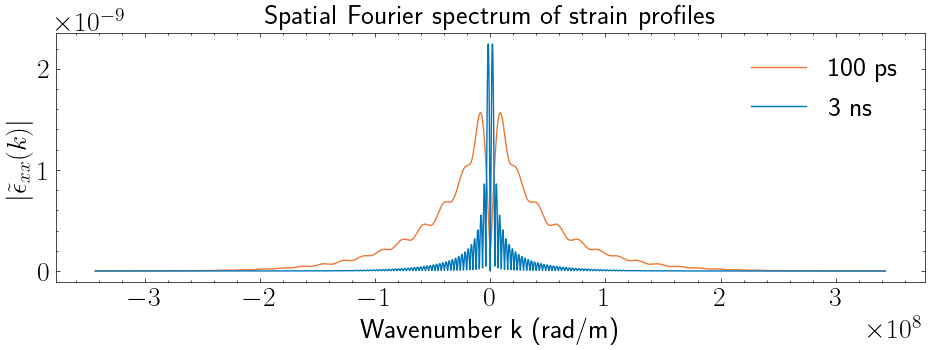

In [136]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq, fftshift

def spatial_fft(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    dx = np.mean(np.diff(x))
    n = y.size

    # remove DC offset
    y0 = y - np.mean(y)

    # normalized FFT
    yk = fft(y0) * dx
    k_cycles = fftfreq(n, d=dx)          # cycles / m
    k_rad = 2.0 * np.pi * k_cycles       # rad / m

    return fftshift(k_cycles), fftshift(k_rad), fftshift(np.abs(yk))

# 100 ps
f_100, k_100, amp_100 = spatial_fft(profile_xs_m_100ps, profile_exx_100ps)

# 3 ns
f_3ns, k_3ns, amp_3ns = spatial_fft(profile_xs_m_3ns, profile_exx_3ns)

plt.figure(figsize=(10, 4))
plt.plot(k_100, amp_100, label="100 ps")
plt.plot(k_3ns, amp_3ns, label="3 ns")
plt.xlabel("Wavenumber k (rad/m)")
plt.ylabel(r"$|\tilde{\epsilon}_{xx}(k)|$")
plt.title("Spatial Fourier spectrum of strain profiles")
plt.legend()
plt.tight_layout()
plt.show()

In [137]:
import numpy as np
from scipy.fft import fft, fftfreq

def low_k_weight(x, y, k_cut):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    dx = np.mean(np.diff(x))
    n = y.size

    # remove DC (important)
    y0 = y - np.mean(y)

    # Fourier transform (proper normalization)
    Y = fft(y0) * dx
    k = 2 * np.pi * fftfreq(n, d=dx)   # rad/m

    # power spectrum
    power = np.abs(Y)**2

    # low-k mask
    mask = np.abs(k) < k_cut

    # integrals (discrete sum ~ integral)
    dk = np.abs(k[1] - k[0])

    low_weight = np.sum(power[mask]) * dk
    total_weight = np.sum(power) * dk

    fraction = low_weight / total_weight

    return low_weight, fraction

In [138]:
k_cut = 5e6 * 2*np.pi   # adjust based on your scale

low_100, frac_100 = low_k_weight(profile_xs_m_100ps, profile_exx_100ps, k_cut)
low_3ns, frac_3ns = low_k_weight(profile_xs_m_3ns, profile_exx_3ns, k_cut)

print("100 ps: absolute =", low_100, "fraction =", frac_100)
print("3 ns:  absolute =", low_3ns, "fraction =", frac_3ns)

100 ps: absolute = 7.807775164100493e-11 fraction = 0.7443671342994704
3 ns:  absolute = 2.3570704785460826e-11 fraction = 0.9919666310113406
